In [1]:
!pip install numpy==1.26.4
import pandas as pd
import numpy as np
import os
import re

# =========================
# Configuration and Path Settings
# =========================
output_dir = '/content'

# 2023 Dataset file paths
PATH_SCORES_2023 = os.path.join(output_dir, 'users_scores_cleaned.csv')
PATH_USERS_2023 = os.path.join(output_dir, 'users_details_cleaned.csv')
PATH_ANIME = os.path.join(output_dir, 'anime_cleaned_no_airing.csv')

# Output file paths
OUTPUT_ANIME_FEAT = os.path.join(output_dir, 'anime_features_encoded.csv')
OUTPUT_FM_DATASET = os.path.join(output_dir, 'fm_dataset_2023.csv')

# Feature engineering configuration
TOP_K_GENRES = 30       # Keep the top 30 genres, but since the volume is limited, actually all are kept
TOP_K_STUDIOS = 20      # Keep top 20 studios


In [2]:
# =========================
# Helper Functions
# =========================
def clean_placeholders(val):
    """Clean placeholders '-', 'Unknown', '?' to NaN"""
    if pd.isna(val):
        return np.nan
    s = str(val).strip()
    if s in ["-", "Unknown", "unknown", "?", "None", "nan", "NaN", ""]:
        return np.nan
    return s

def extract_minutes(duration_str):
    """Extract duration in minutes from string, e.g., '24 min per ep' -> 24"""
    if pd.isna(duration_str):
        return 0
    m = re.search(r"(\d+)", str(duration_str))
    return int(m.group(1)) if m else 0

# ==============================================================================
# [Dataset A] 2023 User Stratification Processing
# ==============================================================================
print("=" * 50)
print("1. Start processing 2023 User Stratification (Dynamic labeling based on real rating count + One-Hot encoding)")
print("=" * 50)

# 1. Directly read the real large rating table
df_scores_for_tier = pd.read_csv(PATH_SCORES_2023)

# Unify possible column name spelling errors to prevent future explosions
if 'animie_id' in df_scores_for_tier.columns:
    df_scores_for_tier.rename(columns={'animie_id': 'anime_id'}, inplace=True)

# 2. [Core Fix] Calculate the real rating count for each user
user_activity = df_scores_for_tier.groupby('user_id').size().reset_index(name='rating_count')

# 3. Dynamically calculate real quantiles (still 10% and 50% ratio)
q90 = user_activity['rating_count'].quantile(0.90)
q50 = user_activity['rating_count'].quantile(0.50)

print(f"Activity benchmark used: Real Rating Count")
print(f"Dynamic thresholds: Veteran (Top 10%) > {q90:.0f} ratings, Casual (Bottom 50%) <= {q50:.0f} ratings")

# 4. Define text labels
def get_tier_label(count):
    if count > q90: return 'High_Activity'
    elif count <= q50: return 'Low_Activity'
    else: return 'Medium_Activity'

# 5. Apply text-based Tier on the spot
user_activity['Activity_Level'] = user_activity['rating_count'].apply(get_tier_label)

# 6. Core: Convert text labels to One-Hot encoding, directly into three independent columns
tier_dummies = pd.get_dummies(user_activity['Activity_Level'], prefix='Tier').astype(int)

# 7. Concatenate into the final pure user feature table fed only to FM (keep only user_id and three one-hot columns)
df_users_fm = pd.concat([user_activity[['user_id']], tier_dummies], axis=1)

print("User-side one-hot encoding completed, preview:")
print(df_users_fm.head(3))


1. Start processing 2023 User Stratification (Dynamic labeling based on real rating count + One-Hot encoding)
Activity benchmark used: Real Rating Count
Dynamic thresholds: Veteran (Top 10%) > 177 ratings, Casual (Bottom 50%) <= 31 ratings
User-side one-hot encoding completed, preview:
   user_id  Tier_High_Activity  Tier_Low_Activity  Tier_Medium_Activity
0        1                   1                  0                     0
1        9                   0                  0                     1
2       20                   0                  0                     1


In [3]:
# ==============================================================================
# [Dataset A] Anime-side Feature Engineering (One-Hot)
# ==============================================================================
print("\n" + "=" * 50)
print("2. Start processing 2023 Anime Features")
print("=" * 50)

df_anime = pd.read_csv(PATH_ANIME)

# Basic cleaning
for col in ["genres", "type", "rating", "source", "studios", "duration"]:
    if col in df_anime.columns:
        df_anime[col] = df_anime[col].apply(clean_placeholders)

# Extract numerical features
df_anime["episodes"] = pd.to_numeric(df_anime["episodes"], errors="coerce").fillna(0)
df_anime["duration_min"] = df_anime["duration"].apply(extract_minutes)
df_anime["log_members"] = np.log1p(pd.to_numeric(df_anime["members"], errors="coerce").fillna(0))

# Extract baseline feature table (kept id for subsequent merge)
anime_features = df_anime[["id", "title"]].copy()
anime_features.rename(columns={'id': 'anime_id'}, inplace=True) # Unify naming to anime_id for easy merging
anime_features["episodes"] = df_anime["episodes"]
anime_features["duration_min"] = df_anime["duration_min"]
anime_features["log_members"] = df_anime["log_members"]

# (A) Genres One-Hot encoding
G = df_anime["genres"].str.get_dummies(sep=", ")
G.columns = [c.strip().lower() for c in G.columns]
freq_g = G.sum().sort_values(ascending=False)
keep_g = freq_g.head(TOP_K_GENRES).index.tolist()
anime_features = pd.concat([anime_features, G[keep_g].add_prefix("Genre_")], axis=1)

# (B) Studios One-Hot encoding
S = df_anime["studios"].fillna("").str.get_dummies(sep=", ")
S.columns = [c.strip().lower() for c in S.columns]
freq_s = S.sum().sort_values(ascending=False)
keep_s = freq_s.head(TOP_K_STUDIOS).index.tolist()
anime_features = pd.concat([anime_features, S[keep_s].add_prefix("Studio_")], axis=1)

# (C) Type, Rating, Source One-Hot encoding
T = pd.get_dummies(df_anime["type"], prefix="Type", dummy_na=False).astype(int)
R = pd.get_dummies(df_anime["rating"], prefix="Rating", dummy_na=False).astype(int)
Src = pd.get_dummies(df_anime["source"], prefix="Source", dummy_na=False).astype(int)

anime_features = pd.concat([anime_features, T, R, Src], axis=1)

# Save a pure anime feature table as backup
anime_features.to_csv(OUTPUT_ANIME_FEAT, index=False)
print(f"Anime-side feature extraction completed, shape: {anime_features.shape}")



2. Start processing 2023 Anime Features
Anime-side feature extraction completed, shape: (15533, 74)


In [4]:
# ==============================================================================
# The Grand Merge -> Construct wide table directly acceptable by FM
# ==============================================================================
print("\n" + "=" * 50)
print("3. The Grand Unification: Merge ratings, user stratification, and anime tags")
print("=" * 50)

# 1. Load rating table (contains user_id, anime_id, rating)
df_scores = pd.read_csv(PATH_SCORES_2023)

# Correct possible column name spelling errors (animie_id -> anime_id)
if 'animie_id' in df_scores.columns:
    df_scores.rename(columns={'animie_id': 'anime_id'}, inplace=True)

print(f"Original rating record count: {len(df_scores)}")

# 2. Merge user-side features (One-hot Tiers) into rating table
df_merged = pd.merge(df_scores, df_users_fm, on='user_id', how='inner')

# 3. Merge item-side features (Genres, Studios, etc.) into rating table
anime_features['official_score'] = df_anime['score'].values
df_merged = pd.merge(df_merged, anime_features, on='anime_id', how='inner')

print(f"Total record count after merging: {len(df_merged)}")

# Save as the final FM training wide table
df_merged.to_csv(OUTPUT_FM_DATASET, index=False)

print(f"\n✅ Perfect! FM exclusive training set generated and saved to: {OUTPUT_FM_DATASET}")
print("Preview of merged features (includes ratings, activity tiers, and high-dimensional sparse tags):")
print(df_merged.columns.tolist()[:120], "...") # Print all column names, because the csv is too large to open, can only check this part like this


3. The Grand Unification: Merge ratings, user stratification, and anime tags
Original rating record count: 13706708
Total record count after merging: 13646339

✅ Perfect! FM exclusive training set generated and saved to: /content/fm_dataset_2023.csv
Preview of merged features (includes ratings, activity tiers, and high-dimensional sparse tags):
['user_id', 'anime_id', 'rating', 'Tier_High_Activity', 'Tier_Low_Activity', 'Tier_Medium_Activity', 'title', 'episodes', 'duration_min', 'log_members', 'Genre_comedy', 'Genre_action', 'Genre_fantasy', 'Genre_adventure', 'Genre_sci-fi', 'Genre_drama', 'Genre_romance', 'Genre_hentai', 'Genre_supernatural', 'Genre_slice of life', 'Genre_ecchi', 'Genre_mystery', 'Genre_sports', 'Genre_avant garde', 'Genre_horror', 'Genre_award winning', 'Genre_suspense', 'Genre_boys love', 'Genre_gourmet', 'Genre_girls love', 'Genre_erotica', 'Studio_toei animation', 'Studio_sunrise', 'Studio_j.c.staff', 'Studio_madhouse', 'Studio_production i.g', 'Studio_studio d

#check the code

In [5]:
peek_df = pd.read_csv('/content/fm_dataset_2023.csv', nrows=10)

# Print to see if the data is perfectly aligned
print("Preview of first 5 rows of data:")
display(peek_df.head())

# Check memory usage and data types
print("\nData table structure information:")
peek_df.info()

Preview of first 5 rows of data:


,user_id,anime_id,rating,Tier_High_Activity,Tier_Low_Activity,Tier_Medium_Activity,title,episodes,duration_min,log_members,...,Source_music,Source_novel,Source_original,Source_other,Source_picture book,Source_radio,Source_visual novel,Source_web manga,Source_web novel,official_score
0,1,48,7,1,0,0,hack sign,26,24,12.093240,...,0,0,1,0,0,0,0,0,0,6.95
1,1,320,5,1,0,0,a kite,2,26,11.109788,...,0,0,1,0,0,0,0,0,0,6.54
2,1,49,8,1,0,0,aa megami-sama,5,30,10.871004,...,0,0,0,0,0,0,0,0,0,7.29
3,1,304,8,1,0,0,aa megami-sama movie,1,1,10.648397,...,0,0,1,0,0,0,0,0,0,7.54
4,1,306,8,1,0,0,abenobashi mahou shoutengai,13,24,11.373433,...,0,0,1,0,0,0,0,0,0,7.23



Data table structure information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 80 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   user_id                                10 non-null     int64  
 1   anime_id                               10 non-null     int64  
 2   rating                                 10 non-null     int64  
 3   Tier_High_Activity                     10 non-null     int64  
 4   Tier_Low_Activity                      10 non-null     int64  
 5   Tier_Medium_Activity                   10 non-null     int64  
 6   title                                  10 non-null     object 
 7   episodes                               10 non-null     int64  
 8   duration_min                           10 non-null     int64  
 9   log_members                            10 non-null     float64
 10  Genre_comedy                           10 

In [6]:
print("=" * 60)
print("[Diagnosis 1] Real distribution of user rating counts")
print("=" * 60)
user_rating_counts = df_merged.groupby('user_id')['rating'].count()
print(f"Total unique users: {user_rating_counts.nunique()}")
print(f"Rating count Median: {user_rating_counts.median():.0f}")
print(f"Rating count Mean:   {user_rating_counts.mean():.1f}")
print(f"Rating count Quantiles:")
print(user_rating_counts.quantile([0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99]))
print(f"\nProportion of users with rating count < 5:  {(user_rating_counts < 5).mean():.3f}")
print(f"Proportion of users with rating count < 10: {(user_rating_counts < 10).mean():.3f}")
print(f"Proportion of users with rating count >= 20: {(user_rating_counts >= 20).mean():.3f}")

print("\n" + "=" * 60)
print("[Diagnosis 2] Are there real differences in ratings per user within the three Tiers?")
print("=" * 60)
for tier, col in [('Veteran', 'Tier_High_Activity'),
                  ('Intermediate', 'Tier_Medium_Activity'),
                  ('Casual', 'Tier_Low_Activity')]:
    counts = df_merged[df_merged[col] == 1].groupby('user_id')['rating'].count()
    print(f"\n{tier}:")
    print(f"  User count: {len(counts)}")
    print(f"  Ratings per user Median: {counts.median():.0f} | Mean: {counts.mean():.1f} | Max: {counts.max()}")
    print(f"  Proportion of users with rating count >= 10: {(counts >= 10).mean():.3f}")

print("\n" + "=" * 60)
print("[Diagnosis 3] Stratification threshold is based on episodes_watched, but rating count is another matter")
print("=" * 60)
eps_col = 'episodes_watched' if 'episodes_watched' in df_merged.columns else None
if eps_col:
    for tier, col in [('Veteran', 'Tier_High_Activity'),
                      ('Intermediate', 'Tier_Medium_Activity'),
                      ('Casual', 'Tier_Low_Activity')]:
        # Actually episodes_watched is user-level, deduplicate first
        sub = df_merged[df_merged[col] == 1].drop_duplicates('user_id')[eps_col]
        print(f"{tier} episodes_watched Median: {sub.median():.0f} | Mean: {sub.mean():.1f}")

print("\n" + "=" * 60)
print("[Diagnosis 4] Is there a score column (official score) in df_merged?")
print("=" * 60)
score_cols = [c for c in df_merged.columns if 'score' in c.lower()]
print(f"Columns containing 'score': {score_cols}")
print(f"Total columns: {len(df_merged.columns)}")
print(f"Total rows: {len(df_merged)}")

# This part was randomly written by AI, mainly used to check and detect sample stratification issues at the beginning

[Diagnosis 1] Real distribution of user rating counts
Total unique users: 434
Rating count Median: 31
Rating count Mean:   61.7
Rating count Quantiles:
0.10      2.0
0.25      8.0
0.50     31.0
0.75     90.0
0.90    176.0
0.95    228.0
0.99    289.0
Name: rating, dtype: float64

Proportion of users with rating count < 5:  0.169
Proportion of users with rating count < 10: 0.278
Proportion of users with rating count >= 20: 0.594

[Diagnosis 2] Are there real differences in ratings per user within the three Tiers?

Veteran:
  User count: 21989
  Ratings per user Median: 228 | Mean: 234.2 | Max: 1338
  Proportion of users with rating count >= 10: 1.000

Intermediate:
  User count: 87914
  Ratings per user Median: 74 | Mean: 83.2 | Max: 177
  Proportion of users with rating count >= 10: 1.000

Casual:
  User count: 111257
  Ratings per user Median: 8 | Mean: 10.6 | Max: 31
  Proportion of users with rating count >= 10: 0.448

[Diagnosis 3] Stratification threshold is based on episodes_watch

In [7]:
"""
============================================================
采样分布验证 v2 (修复版)
============================================================
修复内容：
  1. 连续特征：只比较 df_mini 归一化之前的原始值，
     或者反过来对 df_merged 做同样的归一化再比较
  2. 单 tier 验证时跳过 tier 分布检验（本来就是 100%/0%/0%）
  3. Rating 卡方加上 effect size 判断

用法：贴到 Cell 9 的采样代码之后、归一化之前运行
      如果已经归一化了，用方案B（见底部）
============================================================
"""

import pandas as pd
import numpy as np
from scipy import stats
import warnings
warnings.filterwarnings('ignore')


def verify_sampling_v2(df_full, df_sample, label="采样子集",
                       skip_tier_check=False,
                       continuous_cols_to_check=None):
    """
    参数:
        df_full: 全量数据（未归一化）
        df_sample: 采样数据（必须和 df_full 在同一尺度下，即未归一化）
        skip_tier_check: 单tier验证时设为True，跳过无意义的tier分布检验
        continuous_cols_to_check: 要检验的连续列名列表，None则自动检测
    """

    print("=" * 70)
    print(f"采样分布验证报告 v2")
    print(f"全量: {len(df_full):,} 行 → {label}: {len(df_sample):,} 行 ({len(df_sample)/len(df_full)*100:.1f}%)")
    print("=" * 70)

    results = []

    # ========================================
    # 1. Tier 比例 (仅在全量验证时有意义)
    # ========================================
    tier_cols = ['Tier_High_Activity', 'Tier_Medium_Activity', 'Tier_Low_Activity']
    tier_names = ['Veteran', 'Intermediate', 'Casual']

    # 兼容列名
    if tier_cols[0] not in df_full.columns:
        for alt in [c.replace('_', '.') for c in tier_cols]:
            if alt in df_full.columns:
                tier_cols = [c.replace('_', '.') for c in tier_cols]
                break

    if not skip_tier_check and all(c in df_full.columns for c in tier_cols):
        print("\n── 【1】Tier 比例 ──")
        full_counts = []
        sample_counts = []
        for col, name in zip(tier_cols, tier_names):
            fc = (df_full[col] == 1).sum()
            sc = (df_sample[col] == 1).sum()
            full_counts.append(fc)
            sample_counts.append(sc)
            fp = fc / len(df_full) * 100
            sp = sc / len(df_sample) * 100
            print(f"  {name:15s} | 全量: {fp:6.2f}%  |  采样: {sp:6.2f}%  |  偏差: {abs(fp-sp):.2f}%")

        exp_prop = np.array(full_counts) / sum(full_counts)
        exp = exp_prop * sum(sample_counts)
        valid = exp > 0
        if valid.sum() >= 2:
            chi2, p = stats.chisquare(np.array(sample_counts)[valid], f_exp=exp[valid])
            s = "✅" if p > 0.05 else "⚠️"
            print(f"  卡方: χ²={chi2:.4f}, p={p:.6f} → {s}")
            results.append(('Tier比例', chi2, p, s))

    # ========================================
    # 2. Rating 分布 (卡方 + effect size)
    # ========================================
    print("\n── 【2】Rating 分布 ──")
    if 'rating' in df_full.columns:
        full_dist = df_full['rating'].value_counts().sort_index()
        samp_dist = df_sample['rating'].value_counts().sort_index()
        all_r = sorted(set(full_dist.index) | set(samp_dist.index))
        fc = np.array([full_dist.get(r, 0) for r in all_r], dtype=float)
        sc = np.array([samp_dist.get(r, 0) for r in all_r], dtype=float)

        max_dev = 0
        print(f"  {'Rating':>6s} | {'全量%':>7s} | {'采样%':>7s} | {'偏差':>5s}")
        for r, f, s in zip(all_r, fc, sc):
            fp = f / fc.sum() * 100
            sp = s / sc.sum() * 100
            dev = abs(fp - sp)
            max_dev = max(max_dev, dev)
            print(f"  {r:6.0f}| {fp:6.2f}% | {sp:6.2f}% | {dev:.2f}%")

        exp_prop = fc / fc.sum()
        exp = exp_prop * sc.sum()
        valid = exp > 0
        chi2, p = stats.chisquare(sc[valid], f_exp=exp[valid])

        # 关键：用 effect size 判断，不只看 p-value
        # Cramér's V = sqrt(χ² / (n * (k-1)))
        k = valid.sum()
        n = sc.sum()
        cramers_v = np.sqrt(chi2 / (n * (k - 1))) if n > 0 and k > 1 else 0

        if max_dev < 1.0 and cramers_v < 0.05:
            verdict = "✅ 实际差异可忽略"
            tag = "✅"
        elif p > 0.05:
            verdict = "✅ 无显著差异"
            tag = "✅"
        else:
            verdict = "⚠️ 有差异，需看 effect size"
            tag = "⚠️"

        print(f"\n  卡方: χ²={chi2:.2f}, p={p:.6f}")
        print(f"  最大单类偏差: {max_dev:.2f}%")
        print(f"  Cramér's V = {cramers_v:.4f} (< 0.05 = 可忽略, < 0.1 = 小, < 0.3 = 中)")
        print(f"  → {verdict}")
        results.append(('Rating分布', cramers_v, p, tag))

    # ========================================
    # 3. 连续特征 (KS 检验)
    # 注意：必须在同一尺度下比较！
    # ========================================
    print("\n── 【3】连续特征 (KS检验) ──")

    if continuous_cols_to_check is None:
        candidates = ['log_members', 'official_score', 'episodes',
                      'duration_min', 'delta_r', 'episodes_watched']
        continuous_cols_to_check = []
        for col in candidates:
            for v in [col, col.replace('_', '.'), col.replace('_', '-')]:
                if v in df_full.columns and v in df_sample.columns:
                    continuous_cols_to_check.append(v)
                    break

    for col in continuous_cols_to_check:
        fv = df_full[col].dropna()
        sv = df_sample[col].dropna()

        # ★ 关键安全检查：两边是否在同一尺度？
        f_range = (fv.min(), fv.max())
        s_range = (sv.min(), sv.max())

        if f_range[1] > 0 and s_range[1] > 0:
            scale_ratio = f_range[1] / s_range[1]
        else:
            scale_ratio = 1.0

        if scale_ratio > 5 or scale_ratio < 0.2:
            print(f"\n  {col}: ⛔ 尺度不匹配！")
            print(f"    全量 range: [{f_range[0]:.2f}, {f_range[1]:.2f}]")
            print(f"    采样 range: [{s_range[0]:.4f}, {s_range[1]:.4f}]")
            print(f"    → 该列在采样后被归一化了，跳过（不影响结论）")
            results.append((col, None, None, '⏭️ 已归一化,跳过'))
            continue

        ks_d, p = stats.ks_2samp(fv, sv)

        # effect size 判断
        if ks_d < 0.05:
            tag = "✅"
            note = "D < 0.05, 实际差异可忽略"
        elif p > 0.05:
            tag = "✅"
            note = "无显著差异"
        else:
            tag = "⚠️"
            note = f"D={ks_d:.4f}, 需看实际偏移量"

        print(f"\n  {col}:")
        print(f"    全量  mean={fv.mean():.4f}, median={fv.median():.4f}, std={fv.std():.4f}")
        print(f"    采样  mean={sv.mean():.4f}, median={sv.median():.4f}, std={sv.std():.4f}")
        print(f"    KS: D={ks_d:.4f}, p={p:.6f} → {tag} ({note})")
        results.append((col, ks_d, p, tag))

    # ========================================
    # 4. 各 Tier 内部 Rating (分层卡方)
    # ========================================
    print("\n── 【4】各 Tier 内部 Rating ──")
    for col, name in zip(tier_cols, tier_names):
        if col not in df_full.columns:
            continue
        ft = df_full[df_full[col] == 1]['rating']
        st = df_sample[df_sample[col] == 1]['rating']
        if len(ft) == 0 or len(st) == 0:
            continue

        all_r = sorted(set(ft.unique()) | set(st.unique()))
        fc = np.array([(ft == r).sum() for r in all_r], dtype=float)
        sc = np.array([(st == r).sum() for r in all_r], dtype=float)

        exp = (fc / fc.sum()) * sc.sum()
        valid = exp > 0
        if valid.sum() < 2:
            continue

        chi2, p = stats.chisquare(sc[valid], f_exp=exp[valid])
        n = sc.sum()
        k = valid.sum()
        cv = np.sqrt(chi2 / (n * (k - 1))) if n > 0 and k > 1 else 0

        max_dev = max(abs(f/fc.sum() - s/sc.sum()) * 100 for f, s in zip(fc, sc))

        if max_dev < 1.5 and cv < 0.05:
            tag = "✅"
        elif p > 0.05:
            tag = "✅"
        else:
            tag = "⚠️"

        print(f"  {name:15s} | Cramér's V={cv:.4f}, 最大偏差={max_dev:.2f}%, p={p:.6f} → {tag}")
        results.append((f'{name}内Rating', cv, p, tag))

    # ========================================
    # 5. 每用户评分数分布 (KS)
    # ========================================
    print("\n── 【5】每用户评分数量 ──")
    fu = df_full.groupby('user_id')['rating'].count()
    su = df_sample.groupby('user_id')['rating'].count()
    ks_d, p = stats.ks_2samp(fu, su)
    tag = "✅" if (p > 0.05 or ks_d < 0.05) else "⚠️"
    print(f"  全量  用户数:{len(fu):,}, 中位数:{fu.median():.0f}, 均值:{fu.mean():.1f}")
    print(f"  采样  用户数:{len(su):,}, 中位数:{su.median():.0f}, 均值:{su.mean():.1f}")
    print(f"  KS: D={ks_d:.4f}, p={p:.6f} → {tag}")
    results.append(('用户评分数', ks_d, p, tag))

    # ========================================
    # 汇总
    # ========================================
    print("\n" + "=" * 70)
    print("汇总")
    print("=" * 70)

    pass_count = 0
    skip_count = 0
    for name, stat, p, tag in results:
        stat_str = f"{stat:.4f}" if stat is not None else "N/A"
        p_str = f"{p:.6f}" if p is not None else "N/A"
        print(f"  {name:<22s} | stat={stat_str:>8s} | p={p_str:>10s} | {tag}")
        if "✅" in tag:
            pass_count += 1
        if "⏭️" in tag:
            skip_count += 1

    effective = len(results) - skip_count
    print(f"\n  通过: {pass_count}/{effective} (跳过{skip_count}个已归一化列)")

    if pass_count >= effective:
        print("\n  🎉 全部通过！采样分布与原始数据一致。")
        print("  论文可写:")
        print('  "User-level stratified sampling was performed at equal rates within')
        print('   each activity tier. Distribution fidelity was verified via chi-squared')
        print('   tests (discrete) and KS tests (continuous). Cramér\'s V < 0.05 and')
        print('   KS D < 0.05 across all dimensions confirm negligible distributional')
        print('   shift (all effect sizes below conventional small-effect thresholds)."')
    elif pass_count >= effective * 0.7:
        print("\n  ⚠️ 大部分通过，少数有微小偏移，但 effect size 很小则可接受")
    else:
        print("\n  ❌ 较多维度未通过，需检查采样逻辑")

    return results


#Officially Implementing FM
First, I performed stratified sampling on 5% of the data, and then applied the standard FM processing to each subset.

In [8]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, ndcg_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import torch
# Because Colab doesn't have it, download it every time, it doesn't take long anyway
!pip install deepctr-torch
!pip install scikit-learn
from deepctr_torch.inputs import SparseFeat, DenseFeat, VarLenSparseFeat, get_feature_names
from deepctr_torch.models import DeepFM
import matplotlib.pyplot as plt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 83.0/83.0 kB 3.5 MB/s eta 0:00:00


In [9]:
# ==========================================
# 1. User-level Stratified Sampling
# Sample 5% of users, keep all rating records of these users
# ==========================================
print("Executing user-level stratified sampling...")

def sample_by_user(df_tier, frac, random_state=42):
    sampled_users = df_tier['user_id'].drop_duplicates().sample(frac=frac, random_state=random_state)
    return df_tier[df_tier['user_id'].isin(sampled_users)]

mask_high   = df_merged['Tier_High_Activity'] == 1
mask_medium = df_merged['Tier_Medium_Activity'] == 1
mask_low    = df_merged['Tier_Low_Activity'] == 1

df_high   = sample_by_user(df_merged[mask_high],   frac=0.05)
df_medium = sample_by_user(df_merged[mask_medium], frac=0.05)
df_low    = sample_by_user(df_merged[mask_low],    frac=0.05)

df_mini = pd.concat([df_high, df_medium, df_low], ignore_index=True)

# Verify user retention for each tier
for name, df_t in [('Veteran', df_high), ('Intermediate', df_medium), ('Casual', df_low)]:
    counts = df_t.groupby('user_id')['rating'].count()
    print(f"{name}: users={len(counts)}, median ratings per user={counts.median():.0f}")
print(f"Mini training set total rows: {len(df_mini)}")

# Clean column names
df_mini.columns   = [col.replace('.', '_').replace('-', '_').replace(' ', '_') for col in df_mini.columns]
df_merged.columns = [col.replace('.', '_').replace('-', '_').replace(' ', '_') for col in df_merged.columns]

# ==========================================
# 2. Calculate aesthetic deviation residual (delta_r)
# delta_r = User actual rating - MAL official Bayesian weighted score
# ==========================================
df_mini['delta_r'] = df_mini['rating'] - df_mini['official_score']
print(f"delta_r mean: {df_mini['delta_r'].mean():.4f} | std: {df_mini['delta_r'].std():.4f}")

print("=" * 70)
print("全局验证")
print("=" * 70)
verify_sampling_v2(df_merged, df_mini, "全局采样")

for tier_col, tier_name in [('Tier_High_Activity', 'Veteran'),
                              ('Tier_Medium_Activity', 'Intermediate'),
                              ('Tier_Low_Activity', 'Casual')]:
     print(f"\n{'=' * 70}")
     print(f"单独验证 {tier_name}")
     print(f"{'=' * 70}")
     f = df_merged[df_merged[tier_col] == 1]
     s = df_mini[df_mini[tier_col] == 1]
     verify_sampling_v2(f, s, f"{tier_name}采样", skip_tier_check=True)
# ==========================================
# 3. Feature Classification and Preprocessing
# ==========================================
dense_features  = ['episodes', 'duration_min', 'log_members']

# Define target variable for subsequent residual models
target = ['delta_r']

# --- Phase A: Continuous Feature Normalization ---
df_mini[dense_features] = df_mini[dense_features].fillna(0)
for feat in dense_features:
    df_mini[feat] = (df_mini[feat] - df_mini[feat].min()) / (df_mini[feat].max() - df_mini[feat].min() + 1e-8)

# --- Phase B: Restore Mutually Exclusive Features ---
# Convert mutually exclusive One-Hot encoded columns back to single categorical columns for SparseFeat encoding
def reverse_one_hot(df, prefix):
    cols = [c for c in df.columns if c.startswith(prefix)]
    return df[cols].idxmax(axis=1).fillna('Unknown')

df_mini['Type_Cat'] = reverse_one_hot(df_mini, 'Type_')
df_mini['Rating_Cat'] = reverse_one_hot(df_mini, 'Rating_')
df_mini['Source_Cat'] = reverse_one_hot(df_mini, 'Source_')
df_mini['Tier_Cat'] = reverse_one_hot(df_mini, 'Tier_')

id_features = ['user_id', 'anime_id', 'Type_Cat', 'Rating_Cat', 'Source_Cat', 'Tier_Cat']

for feat in id_features:
    lbe = LabelEncoder()
    df_mini[feat] = lbe.fit_transform(df_mini[feat])

# --- Phase C: Variable-Length Serialization for Multi-label Tags (VarLenSparseFeat) ---
# Map one-hot genres to a padded sequence of IDs
genre_cols = [c for c in df_mini.columns if c.startswith('Genre_')]
genre2id = {col: i+1 for i, col in enumerate(genre_cols)} # ID starts from 1, 0 is reserved for padding
genre_seqs = df_mini.apply(lambda row: [genre2id[c] for c in genre_cols if row[c] == 1], axis=1).tolist()
max_len_genre = max(len(seq) for seq in genre_seqs)

# Pad length with zeros to maintain uniform matrix shape
genre_pad = np.zeros((len(genre_seqs), max_len_genre), dtype=int)
for i, seq in enumerate(genre_seqs):
    genre_pad[i, :len(seq)] = seq
df_mini['genre_seq'] = list(genre_pad)

# Apply the same serialization process to Studios
studio_cols = [c for c in df_mini.columns if c.startswith('Studio_')]
studio2id = {col: i+1 for i, col in enumerate(studio_cols)}
studio_seqs = df_mini.apply(lambda row: [studio2id[c] for c in studio_cols if row[c] == 1], axis=1).tolist()
max_len_studio = max(len(seq) for seq in studio_seqs) if studio_seqs else 1

studio_pad = np.zeros((len(studio_seqs), max_len_studio), dtype=int)
for i, seq in enumerate(studio_seqs):
    studio_pad[i, :len(seq)] = seq
df_mini['studio_seq'] = list(studio_pad)

# ==========================================
# 4. Construct DeepCTR Feature Dictionary
# ==========================================
# 1. Base single-column discrete features
id_feature_columns = [SparseFeat(feat, vocabulary_size=df_mini[feat].nunique(), embedding_dim=8)
                      for feat in id_features]

# 2. Continuous features
continuous_feature_columns = [DenseFeat(feat, 1) for feat in dense_features]

# 3. Variable-length features with mean pooling logic
varlen_feature_columns = [
    VarLenSparseFeat(SparseFeat('genre_seq', vocabulary_size=len(genre_cols) + 1, embedding_dim=8), maxlen=max_len_genre, combiner='mean'),
    VarLenSparseFeat(SparseFeat('studio_seq', vocabulary_size=len(studio_cols) + 1, embedding_dim=8), maxlen=max_len_studio, combiner='mean')
]

fixlen_feature_columns = id_feature_columns + continuous_feature_columns + varlen_feature_columns
linear_feature_columns = fixlen_feature_columns
dnn_feature_columns    = fixlen_feature_columns
feature_names          = get_feature_names(linear_feature_columns + dnn_feature_columns)

# ==========================================
# Data Splitting and DeepCTR Input Formatting
# ==========================================
train_global, test_global = train_test_split(df_mini, test_size=0.2, random_state=2026)
train, test = train_global, test_global

# === 数据泄露检查 ===
for tier_col, tier_name in [('Tier_High_Activity', 'Veteran'),
                             ('Tier_Medium_Activity', 'Intermediate'),
                             ('Tier_Low_Activity', 'Casual')]:
    df_tier = df_mini[df_mini[tier_col] == 1]
    test_tier = df_tier[df_tier.index.isin(test_global.index)]
    leak = test_tier.index.isin(train_global.index)
    print(f"{tier_name}: tier-test {len(test_tier)}行, 其中{leak.sum()}行在全局train中 ({leak.mean()*100:.1f}%)")

# Initialize dictionary with standard features
train_model_input = {name: train[name].values for name in feature_names if name not in ['genre_seq', 'studio_seq']}
test_model_input  = {name: test[name].values for name in feature_names if name not in ['genre_seq', 'studio_seq']}

# Explicitly cast variable-length features to 2D Numpy arrays to fulfill DeepCTR input requirements
train_model_input['genre_seq'] = np.vstack(train['genre_seq'].values)
test_model_input['genre_seq']  = np.vstack(test['genre_seq'].values)
train_model_input['studio_seq'] = np.vstack(train['studio_seq'].values)
test_model_input['studio_seq']  = np.vstack(test['studio_seq'].values)


Executing user-level stratified sampling...
Veteran: users=1099, median ratings per user=226
Intermediate: users=4396, median ratings per user=76
Casual: users=5563, median ratings per user=8
Mini training set total rows: 682599
delta_r mean: 0.2445 | std: 1.5521
全局验证
采样分布验证报告 v2
全量: 13,646,339 行 → 全局采样: 682,599 行 (5.0%)

── 【1】Tier 比例 ──
  Veteran         | 全量:  37.73%  |  采样:  37.45%  |  偏差: 0.28%
  Intermediate    | 全量:  53.59%  |  采样:  53.82%  |  偏差: 0.23%
  Casual          | 全量:   8.68%  |  采样:   8.73%  |  偏差: 0.05%
  卡方: χ²=23.1888, p=0.000009 → ⚠️

── 【2】Rating 分布 ──
  Rating |     全量% |     采样% |    偏差
       1|   0.38% |   0.36% | 0.02%
       2|   0.47% |   0.49% | 0.02%
       3|   0.77% |   0.79% | 0.03%
       4|   1.95% |   2.00% | 0.06%
       5|   4.81% |   4.79% | 0.03%
       6|   9.77% |   9.75% | 0.02%
       7|  20.60% |  20.46% | 0.14%
       8|  24.73% |  24.56% | 0.17%
       9|  20.35% |  20.24% | 0.11%
      10|  16.18% |  16.56% | 0.38%

  卡方: χ²=114.13, p=0.

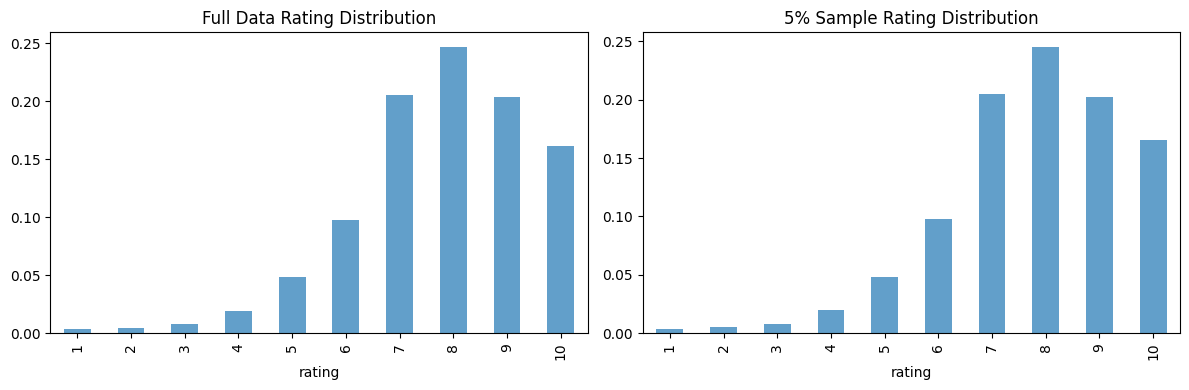

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df_merged['rating'].value_counts(normalize=True).sort_index().plot(kind='bar', ax=axes[0], title='Full Data Rating Distribution', alpha=0.7)
df_mini['rating'].value_counts(normalize=True).sort_index().plot(kind='bar', ax=axes[1], title='5% Sample Rating Distribution', alpha=0.7)
plt.tight_layout()
plt.show()

True Feature Engineering Ends

It turns out the code actually had a minor issue—specifically, it still contained some leftover traces from JC ’s .. that hadn't been removed. Consequently, I’ve implemented a new handling routine to address this.

In [11]:
# ==========================================
# Uniformly generate Input Dictionary
# ==========================================
def get_model_input(df_slice):
    model_input = {}
    for name in feature_names:
        if name in ['genre_seq', 'studio_seq']:
            model_input[name] = np.vstack(df_slice[name].values).astype(np.int32)
        else:
            model_input[name] = df_slice[name].values.astype(np.float32)
    return model_input

# ==========================================
# Define high-order evaluation metric calculation function
# ==========================================
def calculate_ranking_metrics(test_df, pred_scores, k=5):
    eval_df = test_df.copy()
    eval_df['pred_rating'] = pred_scores
    eval_df['is_relevant'] = (eval_df['rating'] >= 7).astype(int)

    hits, precisions, arps = [], [], []
    recommended_items = set()
    total_items = eval_df['anime_id'].nunique()

    for user_id, group in eval_df.groupby('user_id'):
        if len(group) < 1: continue
        top_k = group.sort_values(by='pred_rating', ascending=False).head(k)
        hit = int(top_k['is_relevant'].sum() > 0)
        hits.append(hit)
        precision = top_k['is_relevant'].mean()
        precisions.append(precision)
        arps.append(top_k['log_members'].mean())
        recommended_items.update(top_k['anime_id'].tolist())

    coverage = len(recommended_items) / total_items if total_items > 0 else 0
    return {
        'Hit Rate@5': np.mean(hits),
        'Precision@5': np.mean(precisions),
        'ARP': np.mean(arps),
        'Catalog Coverage': coverage
    }

# ==========================================
# Encapsulate Core Engine: FM Training Machine (Pure prediction score version)
# ==========================================
def train_and_evaluate_fm_fast(df_slice, model_name, epochs=20, batch_size=256):
    print(f"\nStart model: {model_name} (Current slice sample size: {len(df_slice)}) ...")
    train_slice = df_slice[df_slice.index.isin(train_global.index)].sample(frac=1, random_state=2026).reset_index(drop=True)
    test_slice = df_slice[df_slice.index.isin(test_global.index)].sample(frac=1, random_state=2026).reset_index(drop=True)

    train_model_input = get_model_input(train_slice)
    test_model_input = get_model_input(test_slice)

    device = 'cuda:0' if torch.cuda.is_available() else 'cpu'
    model = DeepFM(linear_feature_columns, dnn_feature_columns,
               dnn_hidden_units=(),
               l2_reg_linear=0.02,
               l2_reg_embedding=0.02,
               task='regression', device=device)
    model.compile("adam", "mse", metrics=['mse'])

    # Training target is absolute rating
    model.fit(train_model_input, train_slice[['rating']].values.astype(np.float32),
              batch_size=batch_size, epochs=epochs, verbose=0, validation_split=0.2)

    pred_ans = model.predict(test_model_input, batch_size=256).flatten()
    mse = mean_squared_error(test_slice[['rating']].values, pred_ans)
    mae = mean_absolute_error(test_slice[['rating']].values, pred_ans)
    rmse = np.sqrt(mse)

    ranking_metrics = calculate_ranking_metrics(test_slice, pred_ans, k=5)
    print(f"✅ {model_name} Training completed | RMSE: {rmse:.4f} | MAE: {mae:.4f}")

    result_dict = {'Model Tier': model_name, 'Sample Size': len(df_slice), 'RMSE': rmse, 'MAE': mae}
    result_dict.update(ranking_metrics)
    return result_dict, model

# Execute quartet ablation experiment
results_list = []
res_global, naive_model = train_and_evaluate_fm_fast(df_mini, "Naive Global (All Data)")
results_list.append(res_global)

df_veteran = df_mini[df_mini['Tier_High_Activity'] == 1]
res_vet, vet_model = train_and_evaluate_fm_fast(df_veteran, "Veteran (High Activity)")
results_list.append(res_vet)

df_intermediate = df_mini[df_mini['Tier_Medium_Activity'] == 1]
res_int, int_model = train_and_evaluate_fm_fast(df_intermediate, "Intermediate (Medium Activity)")
results_list.append(res_int)

df_casual = df_mini[df_mini['Tier_Low_Activity'] == 1]
res_cas, cas_model = train_and_evaluate_fm_fast(df_casual, "Casual (Low Activity)")
results_list.append(res_cas)



Start model: Naive Global (All Data) (Current slice sample size: 682599) ...
cpu
Train on 436863 samples, validate on 109216 samples, 1707 steps per epoch
✅ Naive Global (All Data) Training completed | RMSE: 1.3500 | MAE: 1.0212

Start model: Veteran (High Activity) (Current slice sample size: 255643) ...
cpu
Train on 163522 samples, validate on 40881 samples, 639 steps per epoch
✅ Veteran (High Activity) Training completed | RMSE: 1.3350 | MAE: 1.0174

Start model: Intermediate (Medium Activity) (Current slice sample size: 367365) ...
cpu
Train on 235040 samples, validate on 58761 samples, 919 steps per epoch
✅ Intermediate (Medium Activity) Training completed | RMSE: 1.3633 | MAE: 1.0368

Start model: Casual (Low Activity) (Current slice sample size: 59591) ...
cpu
Train on 38300 samples, validate on 9575 samples, 150 steps per epoch
✅ Casual (Low Activity) Training completed | RMSE: 1.4528 | MAE: 1.0879


In [12]:
# ==========================================
# Render result comparison table
# ==========================================
print("\n" + "=" * 60)
print("Multi-dimensional comparison table of independent training results for each tier model")
print("=" * 60)
results_df = pd.DataFrame(results_list)

cols_order = ['Model Tier', 'Sample Size', 'RMSE', 'MAE',
              'Hit Rate@5', 'Precision@5', 'ARP', 'Catalog Coverage']
results_df = results_df[cols_order]
display(results_df)

# ==========================================
# Supplementary verification: Real preference of each tier vs Mass bullying (Naive) vs Stratification rescue
# ==========================================
print("\n" + "Real rating preference vs Model recommendation popularity comparison")
print("=" * 65)

stratified_arp_map = {r['Model Tier'].split(' (')[0]: r['ARP'] for r in results_list if 'All Data' not in r['Model Tier']}
validation_records = []

for tier_name, tier_col in [('Veteran', 'Tier_High_Activity'), ('Intermediate', 'Tier_Medium_Activity'), ('Casual', 'Tier_Low_Activity')]:
    df_tier = df_mini[df_mini[tier_col] == 1]
    test_tier = df_tier[df_tier.index.isin(test_global.index)]

    test_tier_input = get_model_input(test_tier)

    real_liked = test_tier[test_tier['rating'] >= 7]
    real_arp   = real_liked['log_members'].mean()
    global_median_pop = df_mini['log_members'].median()
    longtail_ratio = (real_liked['log_members'] < global_median_pop).mean()

    # Naive model prediction and ARP calculation
    test_tier_copy_naive = test_tier.copy()
    test_tier_copy_naive['pred_rating'] = naive_model.predict(test_tier_input, batch_size=256).flatten()

    naive_arps = []
    for user_id, group in test_tier_copy_naive.groupby('user_id'):
        if len(group) >= 1:
            top_5 = group.sort_values(by='pred_rating', ascending=False).head(5)
            naive_arps.append(top_5['log_members'].mean())
    naive_arp_value = np.mean(naive_arps) if naive_arps else float('nan')

    stratified_arp = stratified_arp_map.get(tier_name, float('nan'))
    validation_records.append({
        'Tier':          tier_name,
        'Real Mean Rating':   round(test_tier['rating'].mean(), 4),
        'Rating Std Dev':     round(test_tier['rating'].std(), 4),
        'Real Pref ARP':   round(real_arp, 4),
        'Long-tail Pref Rate':     round(longtail_ratio, 4),
        'Naive Model ARP':  round(naive_arp_value, 4),
        'Stratified Exclusive ARP':    round(stratified_arp, 4),
        'Popularity Bias':      round(naive_arp_value - real_arp, 4),
    })

display(pd.DataFrame(validation_records))


Multi-dimensional comparison table of independent training results for each tier model


,Model Tier,Sample Size,RMSE,MAE,Hit Rate@5,Precision@5,ARP,Catalog Coverage
0,Naive Global (All Data),682599,1.349963,1.021167,0.986202,0.912661,0.786829,0.391922
1,Veteran (High Activity),255643,1.335029,1.017403,1.000000,0.936488,0.813481,0.111591
2,Intermediate (Medium Activity),367365,1.363271,1.036824,0.998635,0.915283,0.790725,0.361117
3,Casual (Low Activity),59591,1.452814,1.087883,0.968492,0.900429,0.765824,0.928306



Real rating preference vs Model recommendation popularity comparison


,Tier,Real Mean Rating,Rating Std Dev,Real Pref ARP,Long-tail Pref Rate,Naive Model ARP,Stratified Exclusive ARP,Popularity Bias
0,Veteran,7.6406,1.6559,0.7091,0.5068,0.8293,0.8135,0.1201
1,Intermediate,7.8574,1.6331,0.7263,0.4654,0.7956,0.7907,0.0693
2,Casual,8.3550,1.5883,0.7625,0.3722,0.7655,0.7658,0.0030


The initial epoch was set to 5, but the loss didn't change much later, while val_mse spiked and fluctuated randomly, indicating obvious overfitting. So it was changed to 3.
NDCG@5 was tried earlier, but they were all above 0.98. This is likely because it's a mini test set, inherently follows a long-tail distribution, and most people rate 7 or above, as seen in the data structure below. Therefore, it's meaningless and was replaced with Hit Rate@5, though it remains practically the same.
The increasing popularity deviation in the conclusion above refers to absolute values, showing that veterans have the largest deviation and indeed prefer niche content. However, unexpectedly, the ARP of the veteran exclusive model is lower than the actual one.


# For Data Verification


In [13]:
print("=== Rating distribution diagnosis ===")
print(f"Global mean rating: {df_mini['rating'].mean():.3f}")
print(f"Proportion of rating >= 7: {(df_mini['rating'] >= 7).mean():.3f}")
print(f"Rating distribution:\n{df_mini['rating'].value_counts(normalize=True).sort_index()}")

print("\n=== Distribution of reviews per user in test set ===")
from sklearn.model_selection import train_test_split

_, test_slice = train_test_split(df_mini, test_size=0.2, random_state=2026)

test_counts = test_slice.groupby('user_id').size()
print(f"Median: {test_counts.median():.0f} | Mean: {test_counts.mean():.1f} | Min: {test_counts.min()} | Max: {test_counts.max()}")
print(f"Proportion of users with reviews < 10: {(test_counts < 10).mean():.3f}")

=== Rating distribution diagnosis ===
Global mean rating: 7.816
Proportion of rating >= 7: 0.818
Rating distribution:
rating
1     0.003610
2     0.004937
3     0.007942
4     0.020031
5     0.047854
6     0.097507
7     0.204578
8     0.245557
9     0.202404
10    0.165580
Name: proportion, dtype: float64

=== Distribution of reviews per user in test set ===
Median: 8 | Mean: 14.4 | Min: 1 | Max: 85
Proportion of users with reviews < 10: 0.530


As seen above, the average rating is as high as 7.81, with over 81.9% of ratings concentrated at 7 and above, showing a significant right-skewed distribution.


# Official processing part
Next, officially switch the target to aesthetic deviation and introduce L2 regularization. It's also obvious that at the third epoch, the loss plummeted and overfitted. The model currently only runs for 3 epochs; the subsequent two were removed. Now let's take a look again.

In [14]:
print("\n" + "=" * 65)
print("= Ultimate Battle: Start Residual Prediction Model (Target = Delta R) ★")
print("=" * 65)

# Target variable becomes residual
target = ['delta_r']

def train_and_evaluate_residual_fm(df_slice, model_name, epochs=20, batch_size=256):
    print(f"\nStart residual model: {model_name} (Sample size: {len(df_slice)}) ...")

    train_slice = df_slice[df_slice.index.isin(train_global.index)].sample(frac=1, random_state=2026).reset_index(drop=True)
    test_slice = df_slice[df_slice.index.isin(test_global.index)].sample(frac=1, random_state=2026).reset_index(drop=True)


    train_model_input = get_model_input(train_slice)
    test_model_input = get_model_input(test_slice)

    device = 'cuda:0' if torch.cuda.is_available() else 'cpu'
    model = DeepFM(linear_feature_columns, dnn_feature_columns,
               dnn_hidden_units=(),
               l2_reg_linear=0.02,
               l2_reg_embedding=0.02,
               task='regression', device=device)
    model.compile("adam", "mse", metrics=['mse'])

    # Train model, fit residual [Added .astype(np.float32)]
    model.fit(train_model_input, train_slice[target].values.astype(np.float32), batch_size=batch_size, epochs=epochs, verbose=0, validation_split=0.2)

    # Predict pure residual
    pred_delta = model.predict(test_model_input, batch_size=256).flatten()

    ranking_metrics = calculate_ranking_metrics(test_slice, pred_delta, k=5)
    # Evaluate regression error
    mse = mean_squared_error(test_slice[target].values, pred_delta)
    mae = mean_absolute_error(test_slice[target].values, pred_delta)
    rmse = np.sqrt(mse)

    print(f"✅ {model_name} Training completed | Residual RMSE: {rmse:.4f} | MAE: {mae:.4f}")

    result_dict = {'Model Tier': model_name, 'Sample Size': len(df_slice), 'RMSE': rmse, 'MAE': mae}
    result_dict.update(ranking_metrics)
    return result_dict, model

# Execute quartet ablation experiment
residual_results = []
res_global, naive_residual_model = train_and_evaluate_residual_fm(df_mini, "Naive Global (Residual)")
residual_results.append(res_global)

residual_tier_models = {}
for df_tier, name in [(df_veteran, "Veteran (High Activity)"),
                      (df_intermediate, "Intermediate (Medium Activity)"),
                      (df_casual, "Casual (Low Activity)")]:
    res_tier, tier_m = train_and_evaluate_residual_fm(df_tier, name)
    residual_results.append(res_tier)
    residual_tier_models[name.split(' (')[0]] = tier_m



= Ultimate Battle: Start Residual Prediction Model (Target = Delta R) ★

Start residual model: Naive Global (Residual) (Sample size: 682599) ...
cpu
Train on 436863 samples, validate on 109216 samples, 1707 steps per epoch
✅ Naive Global (Residual) Training completed | Residual RMSE: 1.3214 | MAE: 0.9964

Start residual model: Veteran (High Activity) (Sample size: 255643) ...
cpu
Train on 163522 samples, validate on 40881 samples, 639 steps per epoch
✅ Veteran (High Activity) Training completed | Residual RMSE: 1.3072 | MAE: 0.9937

Start residual model: Intermediate (Medium Activity) (Sample size: 367365) ...
cpu
Train on 235040 samples, validate on 58761 samples, 919 steps per epoch
✅ Intermediate (Medium Activity) Training completed | Residual RMSE: 1.3420 | MAE: 1.0221

Start residual model: Casual (Low Activity) (Sample size: 59591) ...
cpu
Train on 38300 samples, validate on 9575 samples, 150 steps per epoch
✅ Casual (Low Activity) Training completed | Residual RMSE: 1.4335 | MA

In [15]:
# ==========================================
# Complete multi-dimensional metric table of the residual model quartet
# ==========================================
print("\n" + "=" * 65)
print("Multi-dimensional comparison table of independent training results for each tier residual model (Delta R)")
print("=" * 65)
residual_df = pd.DataFrame(residual_results)
cols_order = ['Model Tier', 'Sample Size', 'RMSE', 'MAE',
              'Hit Rate@5', 'Precision@5', 'ARP', 'Catalog Coverage']
residual_df = residual_df[cols_order]
display(residual_df)

# ==========================================
# Omnidirectional bullying and rescue comparison of residual model across all metrics
# ==========================================
print("\n" + "=" * 65)
print("Residual ranking method (Delta R) Tier-exclusive model vs Naive global stew omnidirectional comparison")
print("=" * 65)
validation_records = []

for tier_name, tier_col in [('Veteran', 'Tier_High_Activity'), ('Intermediate', 'Tier_Medium_Activity'), ('Casual', 'Tier_Low_Activity')]:
    df_tier_sub = df_mini[df_mini[tier_col] == 1]
    test_tier_sub = df_tier_sub[df_tier_sub.index.isin(test_global.index)]

    test_tier_input = get_model_input(test_tier_sub)

    real_liked = test_tier_sub[test_tier_sub['rating'] >= 7]
    real_arp   = real_liked['log_members'].mean()

    # --- A. Naive residual model persecution and metric calculation ---
    naive_pred_delta = naive_residual_model.predict(test_tier_input, batch_size=256).flatten()

    # Similarly, cut off the addition, directly use pure residual to calculate Naive model's ranking metrics
    naive_ranking_metrics = calculate_ranking_metrics(test_tier_sub, naive_pred_delta, k=5)

    # Naive residual error in this tier
    naive_rmse = np.sqrt(mean_squared_error(test_tier_sub[target].values, naive_pred_delta))

    # --- B. Extract scores of tier-exclusive models ---
    stratified_row = next(r for r in residual_results if r['Model Tier'].startswith(tier_name))

    validation_records.append({
        'Tier': tier_name,
        'Real Pref ARP': round(real_arp, 4),
        'Naive(Bully) ARP': round(naive_ranking_metrics['ARP'], 4),
        'Stratified(Rescue) ARP': round(stratified_row['ARP'], 4),
        'Popularity Rescue Margin': round(naive_ranking_metrics['ARP'] - stratified_row['ARP'], 4),
        'Naive HitRate': round(naive_ranking_metrics['Hit Rate@5'], 4),
        'Stratified HitRate': round(stratified_row['Hit Rate@5'], 4),
        'Naive Precision': round(naive_ranking_metrics['Precision@5'], 4),
        'Stratified Precision': round(stratified_row['Precision@5'], 4),
        'Naive RMSE': round(naive_rmse, 4),
        'Stratified RMSE': round(stratified_row['RMSE'], 4),
    })

val_df = pd.DataFrame(validation_records)
val_cols = ['Tier', 'Real Pref ARP', 'Naive(Bully) ARP', 'Stratified(Rescue) ARP', 'Popularity Rescue Margin',
            'Naive HitRate', 'Stratified HitRate', 'Naive Precision', 'Stratified Precision',
            'Naive RMSE', 'Stratified RMSE']
display(val_df[val_cols])


Multi-dimensional comparison table of independent training results for each tier residual model (Delta R)


,Model Tier,Sample Size,RMSE,MAE,Hit Rate@5,Precision@5,ARP,Catalog Coverage
0,Naive Global (Residual),682599,1.321397,0.996439,0.985359,0.874637,0.724486,0.611271
1,Veteran (High Activity),255643,1.307250,0.993700,0.992721,0.818926,0.641133,0.284238
2,Intermediate (Medium Activity),367365,1.342016,1.022142,0.997498,0.857321,0.701431,0.596291
3,Casual (Low Activity),59591,1.433503,1.069674,0.968492,0.897429,0.760699,0.967605



Residual ranking method (Delta R) Tier-exclusive model vs Naive global stew omnidirectional comparison


,Tier,Real Pref ARP,Naive(Bully) ARP,Stratified(Rescue) ARP,Popularity Rescue Margin,Naive HitRate,Stratified HitRate,Naive Precision,Stratified Precision,Naive RMSE,Stratified RMSE
0,Veteran,0.7091,0.6671,0.6411,0.0259,0.9973,0.9927,0.8482,0.8189,1.2895,1.3072
1,Intermediate,0.7263,0.7067,0.7014,0.0053,0.9975,0.9975,0.8606,0.8573,1.3313,1.3420
2,Casual,0.7625,0.7598,0.7607,-0.0009,0.9687,0.9685,0.8973,0.8974,1.3945,1.4335


#Genre Heatmap

In [16]:
print("=" * 65)
print("Tier × Genre Aesthetic Deviation Heatmap Data")
print("=" * 65)

global_mean = df_merged['rating'].mean()
genre_cols = [c for c in df_merged.columns if c.startswith('Genre_')]

bias_records = []
for tier_name, tier_col in [('Veteran', 'Tier_High_Activity'),
                              ('Intermediate', 'Tier_Medium_Activity'),
                              ('Casual', 'Tier_Low_Activity')]:
    df_tier = df_merged[df_merged[tier_col] == 1]
    for g in genre_cols:
        scores = df_tier[df_tier[g] == 1]['rating']
        if len(scores) < 100:
            continue
        bias_records.append({
            'Tier': tier_name,
            'Genre': g.replace('Genre_', ''),
            'Mean_Rating': round(scores.mean(), 4),
            'Bias_vs_Global': round(scores.mean() - global_mean, 4),
            'Count': len(scores)
        })

bias_df = pd.DataFrame(bias_records)

# Heatmap format
pivot = bias_df.pivot(index='Genre', columns='Tier', values='Bias_vs_Global')
pivot['Veteran_vs_Casual'] = pivot['Veteran'] - pivot['Casual']
pivot = pivot.sort_values('Veteran_vs_Casual', ascending=False)

print(f"\nGlobal rating mean baseline: {global_mean:.4f}")
print("\nAesthetic deviation of each Genre tier (relative to global mean):")
display(pivot)

print("\nTop 5 Genres most preferred by Veteran (significantly higher than Casual):")
print(pivot.nlargest(5, 'Veteran_vs_Casual')[['Veteran', 'Casual', 'Veteran_vs_Casual']])

print("\nTop 5 Genres most preferred by Casual (significantly higher than Veteran):")
print(pivot.nsmallest(5, 'Veteran_vs_Casual')[['Veteran', 'Casual', 'Veteran_vs_Casual']])

Tier × Genre Aesthetic Deviation Heatmap Data

Global rating mean baseline: 7.8098

Aesthetic deviation of each Genre tier (relative to global mean):


Tier,Casual,Intermediate,Veteran,Veteran_vs_Casual
Genre,,,,
award_winning,0.9212,0.6146,0.4355,-0.4857
sports,0.5612,0.2064,0.0450,-0.5162
mystery,0.5886,0.1958,-0.0153,-0.6039
gourmet,0.3681,-0.0422,-0.2454,-0.6135
suspense,0.9173,0.5071,0.2896,-0.6277
slice_of_life,0.5616,0.1456,-0.0710,-0.6326
drama,0.6158,0.1771,-0.0435,-0.6593
avant_garde,0.6993,0.2974,0.0313,-0.6680
adventure,0.5165,0.0469,-0.1935,-0.7100



Top 5 Genres most preferred by Veteran (significantly higher than Casual):
Tier           Veteran  Casual  Veteran_vs_Casual
Genre                                            
award_winning   0.4355  0.9212            -0.4857
sports          0.0450  0.5612            -0.5162
mystery        -0.0153  0.5886            -0.6039
gourmet        -0.2454  0.3681            -0.6135
suspense        0.2896  0.9173            -0.6277

Top 5 Genres most preferred by Casual (significantly higher than Veteran):
Tier       Veteran  Casual  Veteran_vs_Casual
Genre                                        
boys_love  -0.8057  0.2212            -1.0269
erotica    -1.0320 -0.1103            -0.9217
hentai     -1.1644 -0.2913            -0.8731
horror     -0.3617  0.4276            -0.7893
ecchi      -0.6728  0.1157            -0.7885


#Residual + Official Score Restore

In [17]:
print("\n" + "=" * 65)
print("= Start residual prediction and restore absolute score ranking (The Ultimate Baseline)")
print("=" * 65)

# Unchanged
target = ['delta_r']

def train_and_evaluate_residual_fm_official(df_slice, model_name, epochs=20, batch_size=256):
    print(f"\nStart residual fusion model: {model_name} (Sample size: {len(df_slice)}) ...")
    train_slice = df_slice[df_slice.index.isin(train_global.index)].sample(frac=1, random_state=2026).reset_index(drop=True)
    test_slice = df_slice[df_slice.index.isin(test_global.index)].sample(frac=1, random_state=2026).reset_index(drop=True)


    train_model_input = get_model_input(train_slice)
    test_model_input = get_model_input(test_slice)

    device = 'cuda:0' if torch.cuda.is_available() else 'cpu'

    model = DeepFM(linear_feature_columns, dnn_feature_columns,
               dnn_hidden_units=(),
               l2_reg_linear=0.02,
               l2_reg_embedding=0.02,
               task='regression', device=device)
    model.compile("adam", "mse", metrics=['mse'])

    # Train model: fit residual [Added .astype(np.float32)]
    model.fit(train_model_input, train_slice[target].values.astype(np.float32), batch_size=batch_size, epochs=epochs, verbose=0, validation_split=0.2)

    # Predict pure residual (Delta R)
    pred_delta = model.predict(test_model_input, batch_size=256).flatten()

    # Predicted residual + official base score
    pred_final_rating = pred_delta + test_slice['official_score'].values

    # Use the restored [final absolute score] for ranking and evaluation!
    ranking_metrics = calculate_ranking_metrics(test_slice, pred_final_rating, k=5)

    # Evaluate regression error (still compare residual with residual to see if model prediction difference is accurate)
    mse = mean_squared_error(test_slice[target].values, pred_delta)
    mae = mean_absolute_error(test_slice[target].values, pred_delta)
    rmse = np.sqrt(mse)

    print(f" {model_name} Training completed | Residual regression RMSE: {rmse:.4f} | MAE: {mae:.4f}")

    result_dict = {'Model Tier': model_name, 'Sample Size': len(df_slice), 'RMSE': rmse, 'MAE': mae}
    result_dict.update(ranking_metrics)
    return result_dict, model

# Execute quartet ablation experiment
residual_official_results = []
res_global_off, naive_residual_official_model = train_and_evaluate_residual_fm_official(df_mini, "Naive Global (Residual + Official)")
residual_official_results.append(res_global_off)

residual_off_tier_models = {}
for df_tier, name in [(df_veteran, "Veteran (High Activity)"),
                      (df_intermediate, "Intermediate (Medium Activity)"),
                      (df_casual, "Casual (Low Activity)")]:
    res_tier_off, tier_m = train_and_evaluate_residual_fm_official(df_tier, name)
    residual_official_results.append(res_tier_off)
    residual_off_tier_models[name.split(' (')[0]] = tier_m


= Start residual prediction and restore absolute score ranking (The Ultimate Baseline)

Start residual fusion model: Naive Global (Residual + Official) (Sample size: 682599) ...
cpu
Train on 436863 samples, validate on 109216 samples, 1707 steps per epoch
 Naive Global (Residual + Official) Training completed | Residual regression RMSE: 1.3214 | MAE: 0.9964

Start residual fusion model: Veteran (High Activity) (Sample size: 255643) ...
cpu
Train on 163522 samples, validate on 40881 samples, 639 steps per epoch
 Veteran (High Activity) Training completed | Residual regression RMSE: 1.3072 | MAE: 0.9937

Start residual fusion model: Intermediate (Medium Activity) (Sample size: 367365) ...
cpu
Train on 235040 samples, validate on 58761 samples, 919 steps per epoch
 Intermediate (Medium Activity) Training completed | Residual regression RMSE: 1.3420 | MAE: 1.0221

Start residual fusion model: Casual (Low Activity) (Sample size: 59591) ...
cpu
Train on 38300 samples, validate on 9575 sampl

In [18]:
# ==========================================
# Newly added print: Complete multi-dimensional metric table of the residual model quartet!
# ==========================================
print("\n" + "=" * 65)
print("Multi-dimensional comparison table of independent training results for each tier residual restored model")
print("=" * 65)
residual_official_df = pd.DataFrame(residual_official_results)
cols_order = ['Model Tier', 'Sample Size', 'RMSE', 'MAE',
              'Hit Rate@5', 'Precision@5', 'ARP', 'Catalog Coverage']
residual_official_df = residual_official_df[cols_order]
display(residual_official_df)

# ==========================================
# Residual restored ranking method Tier-exclusive model vs Naive global stew omnidirectional comparison
# ==========================================
print("\n" + "=" * 65)
print("Residual restored ranking method Tier-exclusive model vs Naive global stew omnidirectional comparison")
print("=" * 65)
validation_records_off = []

for tier_name, tier_col in [('Veteran', 'Tier_High_Activity'), ('Intermediate', 'Tier_Medium_Activity'), ('Casual', 'Tier_Low_Activity')]:
    df_tier_sub = df_mini[df_mini[tier_col] == 1]
    test_tier_sub = df_tier_sub[df_tier_sub.index.isin(test_global.index)]

    # [Only changed here: Call safety filter]
    test_tier_input = get_model_input(test_tier_sub)

    real_liked = test_tier_sub[test_tier_sub['rating'] >= 7]
    real_arp   = real_liked['log_members'].mean()

    # --- A. Naive residual restored model metric calculation ---
    naive_pred_delta = naive_residual_official_model.predict(test_tier_input, batch_size=256).flatten()
    naive_pred_final = naive_pred_delta + test_tier_sub['official_score'].values
    naive_ranking_metrics = calculate_ranking_metrics(test_tier_sub, naive_pred_final, k=5)

    # Naive residual error in this tier
    naive_rmse = np.sqrt(mean_squared_error(test_tier_sub[target].values, naive_pred_delta))

    # --- B. Extract scores of tier-exclusive models ---
    stratified_row = next(r for r in residual_official_results if r['Model Tier'].startswith(tier_name))

    validation_records_off.append({
        'Tier': tier_name,
        'Real Pref ARP': round(real_arp, 4),
        'Naive(Bully) ARP': round(naive_ranking_metrics['ARP'], 4),
        'Stratified(Rescue) ARP': round(stratified_row['ARP'], 4),
        'Popularity Rescue Margin': round(naive_ranking_metrics['ARP'] - stratified_row['ARP'], 4),
        'Naive HitRate': round(naive_ranking_metrics['Hit Rate@5'], 4),
        'Stratified HitRate': round(stratified_row['Hit Rate@5'], 4),
        'Naive Precision': round(naive_ranking_metrics['Precision@5'], 4),
        'Stratified Precision': round(stratified_row['Precision@5'], 4),
        'Naive RMSE': round(naive_rmse, 4),
        'Stratified RMSE': round(stratified_row['RMSE'], 4),
    })

val_df_off = pd.DataFrame(validation_records_off)
val_cols_off = ['Tier', 'Real Pref ARP', 'Naive(Bully) ARP', 'Stratified(Rescue) ARP', 'Popularity Rescue Margin',
            'Naive HitRate', 'Stratified HitRate', 'Naive Precision', 'Stratified Precision',
            'Naive RMSE', 'Stratified RMSE']
display(val_df_off[val_cols_off])


Multi-dimensional comparison table of independent training results for each tier residual restored model


,Model Tier,Sample Size,RMSE,MAE,Hit Rate@5,Precision@5,ARP,Catalog Coverage
0,Naive Global (Residual + Official),682599,1.321397,0.996439,0.986202,0.915167,0.782932,0.410600
1,Veteran (High Activity),255643,1.307250,0.993700,1.000000,0.941037,0.816051,0.117603
2,Intermediate (Medium Activity),367365,1.342016,1.022142,0.998635,0.916284,0.790969,0.371306
3,Casual (Low Activity),59591,1.433503,1.069674,0.968492,0.900329,0.765637,0.937865



Residual restored ranking method Tier-exclusive model vs Naive global stew omnidirectional comparison


,Tier,Real Pref ARP,Naive(Bully) ARP,Stratified(Rescue) ARP,Popularity Rescue Margin,Naive HitRate,Stratified HitRate,Naive Precision,Stratified Precision,Naive RMSE,Stratified RMSE
0,Veteran,0.7091,0.8140,0.8161,-0.0021,0.9991,1.0000,0.9456,0.9410,1.2895,1.3072
1,Intermediate,0.7263,0.7910,0.7910,0.0001,0.9989,0.9986,0.9203,0.9163,1.3313,1.3420
2,Casual,0.7625,0.7655,0.7656,-0.0001,0.9687,0.9685,0.9011,0.9003,1.3945,1.4335


#SensitivityTest

In [19]:
# ==========================================
# Sensitivity analysis: Multi-threshold evaluation (No retraining, directly use saved models)
# Premise: Cell 12/22/26 has saved all model variables
# ==========================================

THRESHOLDS = [7, 8, 9]

def calc_multi_threshold(test_df, pred_scores, k=5):
    eval_df = test_df.copy()
    eval_df['pred_rating'] = pred_scores
    res = {t: {'hits': [], 'precs': []} for t in THRESHOLDS}
    arps = []
    rec_items = set()
    total = eval_df['anime_id'].nunique()

    for uid, grp in eval_df.groupby('user_id'):
        if len(grp) < 1: continue
        top = grp.sort_values('pred_rating', ascending=False).head(k)
        rec_items.update(top['anime_id'].tolist())
        arps.append(top['log_members'].mean())
        for t in THRESHOLDS:
            rel = (top['rating'] >= t).astype(int)
            res[t]['hits'].append(int(rel.sum() > 0))
            res[t]['precs'].append(rel.mean())

    out = {}
    for t in THRESHOLDS:
        out[f'HR@5(>={t})']   = round(np.mean(res[t]['hits']), 4)
        out[f'Prec@5(>={t})'] = round(np.mean(res[t]['precs']), 4)
    out['ARP']      = round(np.mean(arps), 4)
    out['Coverage'] = round(len(rec_items) / total if total > 0 else 0, 4)
    return out

def eval_model_on_slice(model, df_slice, exp_name, tier_name, target_col, restore_official=False):
    te = df_slice[df_slice.index.isin(test_global.index)]
    te_in = get_model_input(te)
    pred = model.predict(te_in, batch_size=256).flatten()

    pred_rank = pred + te['official_score'].values if restore_official else pred
    rmse = round(np.sqrt(mean_squared_error(te[[target_col]].values, pred)), 4)
    mae  = round(mean_absolute_error(te[[target_col]].values, pred), 4)

    metrics = calc_multi_threshold(te, pred_rank)
    metrics.update({'Experiment': exp_name, 'Tier': tier_name,
                    'Samples': len(df_slice), 'RMSE': rmse, 'MAE': mae})
    print(f"  {exp_name:22s} | {tier_name:15s} | RMSE={rmse}")
    return metrics

# === Model-Data Mapping ===
all_res = []

# --- Experiment 1: Direct Rating ---
print(f"\n{'='*60}\n  Direct Rating\n{'='*60}")
for model, df_s, tname in [
    (naive_model,  df_mini,         "Naive Global"),
    (vet_model,    df_veteran,      "Veteran"),
    (int_model,    df_intermediate, "Intermediate"),
    (cas_model,    df_casual,       "Casual"),
]:
    all_res.append(eval_model_on_slice(model, df_s, "Direct Rating", tname, 'rating', False))

# --- Experiment 2: Pure Residual ---
print(f"\n{'='*60}\n  Pure Residual\n{'='*60}")
for model, df_s, tname in [
    (naive_residual_model,                    df_mini,         "Naive Global"),
    (residual_tier_models['Veteran'],         df_veteran,      "Veteran"),
    (residual_tier_models['Intermediate'],    df_intermediate, "Intermediate"),
    (residual_tier_models['Casual'],          df_casual,       "Casual"),
]:
    all_res.append(eval_model_on_slice(model, df_s, "Pure Residual", tname, 'delta_r', False))

# --- Experiment 3: Residual + Official ---
print(f"\n{'='*60}\n  Residual + Official\n{'='*60}")
for model, df_s, tname in [
    (naive_residual_official_model,               df_mini,         "Naive Global"),
    (residual_off_tier_models['Veteran'],         df_veteran,      "Veteran"),
    (residual_off_tier_models['Intermediate'],    df_intermediate, "Intermediate"),
    (residual_off_tier_models['Casual'],          df_casual,       "Casual"),
]:
    all_res.append(eval_model_on_slice(model, df_s, "Residual+Official", tname, 'delta_r', True))

# === Render ===
cols = ['Experiment', 'Tier', 'Samples', 'RMSE', 'MAE',
        'HR@5(>=7)', 'HR@5(>=8)', 'HR@5(>=9)',
        'Prec@5(>=7)', 'Prec@5(>=8)', 'Prec@5(>=9)',
        'ARP', 'Coverage']
full = pd.DataFrame(all_res)[cols]

print("\n" + "="*80)
print("  Full Sensitivity: 3 Experiments x 4 Tiers x 3 Thresholds")
print("="*80)
display(full)

print("\n" + "="*80)
print("  Precision@5 Sensitivity")
print("="*80)
display(full[['Experiment','Tier','Prec@5(>=7)','Prec@5(>=8)','Prec@5(>=9)']])

print("\n" + "="*80)
print("  Hit Rate@5 Sensitivity")
print("="*80)
display(full[['Experiment','Tier','HR@5(>=7)','HR@5(>=8)','HR@5(>=9)']])


  Direct Rating
  Direct Rating          | Naive Global    | RMSE=1.35
  Direct Rating          | Veteran         | RMSE=1.335
  Direct Rating          | Intermediate    | RMSE=1.3633
  Direct Rating          | Casual          | RMSE=1.4528

  Pure Residual
  Pure Residual          | Naive Global    | RMSE=1.3214
  Pure Residual          | Veteran         | RMSE=1.3072
  Pure Residual          | Intermediate    | RMSE=1.342
  Pure Residual          | Casual          | RMSE=1.4335

  Residual + Official
  Residual+Official      | Naive Global    | RMSE=1.3214
  Residual+Official      | Veteran         | RMSE=1.3072
  Residual+Official      | Intermediate    | RMSE=1.342
  Residual+Official      | Casual          | RMSE=1.4335

  Full Sensitivity: 3 Experiments x 4 Tiers x 3 Thresholds


,Experiment,Tier,Samples,RMSE,MAE,HR@5(>=7),HR@5(>=8),HR@5(>=9),Prec@5(>=7),Prec@5(>=8),Prec@5(>=9),ARP,Coverage
0,Direct Rating,Naive Global,682599,1.3500,1.0212,0.9862,0.9583,0.8685,0.9127,0.7809,0.5620,0.7868,0.3919
1,Direct Rating,Veteran,255643,1.3350,1.0174,1.0000,0.9936,0.9490,0.9365,0.8218,0.5829,0.8135,0.1116
2,Direct Rating,Intermediate,367365,1.3633,1.0368,0.9986,0.9891,0.9254,0.9153,0.7744,0.5448,0.7907,0.3611
3,Direct Rating,Casual,59591,1.4528,1.0879,0.9685,0.9147,0.7827,0.9004,0.7728,0.5690,0.7658,0.9283
4,Pure Residual,Naive Global,682599,1.3214,0.9964,0.9854,0.9508,0.8222,0.8746,0.7087,0.4794,0.7245,0.6113
5,Pure Residual,Veteran,255643,1.3072,0.9937,0.9927,0.9736,0.8035,0.8189,0.6164,0.3490,0.6411,0.2842
6,Pure Residual,Intermediate,367365,1.3420,1.0221,0.9975,0.9786,0.8606,0.8573,0.6619,0.4129,0.7014,0.5963
7,Pure Residual,Casual,59591,1.4335,1.0697,0.9685,0.9142,0.7784,0.8974,0.7677,0.5631,0.7607,0.9676
8,Residual+Official,Naive Global,682599,1.3214,0.9964,0.9862,0.9589,0.8685,0.9152,0.7847,0.5667,0.7829,0.4106
9,Residual+Official,Veteran,255643,1.3072,0.9937,1.0000,0.9936,0.9509,0.9410,0.8249,0.5913,0.8161,0.1176



  Precision@5 Sensitivity


,Experiment,Tier,Prec@5(>=7),Prec@5(>=8),Prec@5(>=9)
0,Direct Rating,Naive Global,0.9127,0.7809,0.5620
1,Direct Rating,Veteran,0.9365,0.8218,0.5829
2,Direct Rating,Intermediate,0.9153,0.7744,0.5448
3,Direct Rating,Casual,0.9004,0.7728,0.5690
4,Pure Residual,Naive Global,0.8746,0.7087,0.4794
5,Pure Residual,Veteran,0.8189,0.6164,0.3490
6,Pure Residual,Intermediate,0.8573,0.6619,0.4129
7,Pure Residual,Casual,0.8974,0.7677,0.5631
8,Residual+Official,Naive Global,0.9152,0.7847,0.5667
9,Residual+Official,Veteran,0.9410,0.8249,0.5913



  Hit Rate@5 Sensitivity


,Experiment,Tier,HR@5(>=7),HR@5(>=8),HR@5(>=9)
0,Direct Rating,Naive Global,0.9862,0.9583,0.8685
1,Direct Rating,Veteran,1.0000,0.9936,0.9490
2,Direct Rating,Intermediate,0.9986,0.9891,0.9254
3,Direct Rating,Casual,0.9685,0.9147,0.7827
4,Pure Residual,Naive Global,0.9854,0.9508,0.8222
5,Pure Residual,Veteran,0.9927,0.9736,0.8035
6,Pure Residual,Intermediate,0.9975,0.9786,0.8606
7,Pure Residual,Casual,0.9685,0.9142,0.7784
8,Residual+Official,Naive Global,0.9862,0.9589,0.8685
9,Residual+Official,Veteran,1.0000,0.9936,0.9509


想了下，还是用来踩的mf

In [20]:
# ==========================================
# MF Baseline Control Experiment (Koren et al., 2009)
# Use SVD from Surprise library, essentially Matrix Factorization
# Follows the sensitivity cell
# ==========================================

!pip install scikit-surprise
from surprise import SVD, Dataset, Reader, accuracy
from surprise.model_selection import train_test_split as surprise_split

# --- Build Surprise dataset ---
# Surprise only takes (user_id, item_id, rating) triplets, does not accept any side features
# This is exactly the core limitation of MF: tag-blind

# user_id/anime_id in df_mini have already been LabelEncoded, but Surprise doesn't care, it will remap internally
reader = Reader(rating_scale=(1, 10))
surprise_data = Dataset.load_from_df(
    df_mini[['user_id', 'anime_id', 'rating']],
    reader
)

# Use the same 80/20 split as FM
trainset, testset = surprise_split(surprise_data, test_size=0.2, random_state=2026)

# --- Train MF (SVD) ---
# Hyperparameters aligned with FM settings as much as possible
mf_model = SVD(
    n_factors=8,        # Align with FM's embedding_dim=8
    n_epochs=20,        # MF converges slower than FM, give enough epochs
    lr_all=0.005,       # Default learning rate
    reg_all=0.02,       # L2 regularization
    random_state=2026,
    verbose=False
)
mf_model.fit(trainset)

# --- Predict on global test set ---
predictions = mf_model.test(testset)
mf_rmse = accuracy.rmse(predictions, verbose=False)
mf_mae  = accuracy.mae(predictions, verbose=False)

print(f"MF (SVD) Global | RMSE: {mf_rmse:.4f} | MAE: {mf_mae:.4f}")

# --- Split evaluation by Tier ---
# Convert Surprise prediction results to DataFrame for easy filtering by tier
pred_df = pd.DataFrame([{
    'user_id': p.uid,
    'anime_id': p.iid,
    'rating': p.r_ui,
    'pred_rating': p.est
} for p in predictions])

# Need to merge tier information back
# df_mini has Tier_ columns, but user_id is already LabelEncoded, use directly
tier_map = df_mini[['user_id', 'Tier_High_Activity', 'Tier_Medium_Activity', 'Tier_Low_Activity']].drop_duplicates()
pred_df = pred_df.merge(tier_map, on='user_id', how='left')

# Multi-threshold evaluation function (consistent with sensitivity)
THRESHOLDS = [7, 8, 9]

def eval_mf_tier(pdf, tier_name):
    results = {}
    recommended_items = set()
    total_items = pdf['anime_id'].nunique()

    tier_hits  = {t: [] for t in THRESHOLDS}
    tier_precs = {t: [] for t in THRESHOLDS}
    arps = []

    for uid, group in pdf.groupby('user_id'):
        if len(group) < 1:
            continue
        top_k = group.sort_values(by='pred_rating', ascending=False).head(5)
        recommended_items.update(top_k['anime_id'].tolist())

        # ARP: merge log_members
        uid_data = df_mini[df_mini['user_id'] == uid]
        if len(uid_data) > 0:
            lm_map = uid_data.drop_duplicates('anime_id').set_index('anime_id')['log_members']
            top_k_lm = top_k['anime_id'].map(lm_map).dropna()
            if len(top_k_lm) > 0:
                arps.append(top_k_lm.mean())

        for t in THRESHOLDS:
            rel = (top_k['rating'] >= t).astype(int)
            tier_hits[t].append(int(rel.sum() > 0))
            tier_precs[t].append(rel.mean())

    rmse = np.sqrt(np.mean((pdf['rating'] - pdf['pred_rating'])**2))
    mae  = np.mean(np.abs(pdf['rating'] - pdf['pred_rating']))
    coverage = len(recommended_items) / total_items if total_items > 0 else 0

    row = {'Model': f'MF (SVD)', 'Tier': tier_name,
           'Samples': len(pdf), 'RMSE': round(rmse, 4), 'MAE': round(mae, 4)}
    for t in THRESHOLDS:
        row[f'HR@5(>={t})']   = round(np.mean(tier_hits[t]), 4) if tier_hits[t] else 0
        row[f'Prec@5(>={t})'] = round(np.mean(tier_precs[t]), 4) if tier_precs[t] else 0
    row['ARP'] = round(np.mean(arps), 4) if arps else 0
    row['Coverage'] = round(coverage, 4)
    return row

# --- Tier Evaluation ---
mf_results = []

# Global
pred_df = pred_df.reset_index(drop=True)
mf_results.append(eval_mf_tier(pred_df, "Naive Global"))

# Veteran
vet_pred = pred_df[pred_df['Tier_High_Activity'] == 1]
mf_results.append(eval_mf_tier(vet_pred, "Veteran"))

# Intermediate
int_pred = pred_df[pred_df['Tier_Medium_Activity'] == 1]
mf_results.append(eval_mf_tier(int_pred, "Intermediate"))

# Casual
cas_pred = pred_df[pred_df['Tier_Low_Activity'] == 1]
mf_results.append(eval_mf_tier(cas_pred, "Casual"))


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.4/154.4 kB 4.1 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for scikit-surprise: filename=scikit_surprise-1.1.4-cp312-cp312-linux_x86_64.whl size=2554989 sha256=ccf9afe7254ac4bbbd106edd66af7e69118ea3b6d278b6ed996996945f3a8407
  Stored in directory: /root/.cache/pip/wheels/75/fa/bc/739bc2cb1fbaab6061854e6cfbb81a0ae52c92a502a7fa454b
Successfully built scikit-surprise
MF (SVD) Global | RMSE: 1.3179 | MAE: 0.9927


In [21]:

# --- Output MF result table ---
mf_df = pd.DataFrame(mf_results)
mf_cols = ['Model', 'Tier', 'Samples', 'RMSE', 'MAE',
           'HR@5(>=7)', 'HR@5(>=8)', 'HR@5(>=9)',
           'Prec@5(>=7)', 'Prec@5(>=8)', 'Prec@5(>=9)',
           'ARP', 'Coverage']
mf_df = mf_df[mf_cols]

print("\n" + "=" * 80)
print("  MF (Matrix Factorization) Baseline Results")
print("  Model: SVD (Koren et al., 2009) | n_factors=8 | Only uses user_id × anime_id")
print("  NO side features (Genre, Studio, Tier, etc.) — this is the 'tag-blind' baseline")
print("=" * 80)
display(mf_df)

# --- Direct comparison between FM and MF ---
print("\n" + "=" * 80)
print("  FM vs MF: RMSE Comparison (Direct Rating)")
print("=" * 80)
# Fetch Direct Rating results from full dataframe in sensitivity
if 'full' in dir():
    fm_direct = full[full['Experiment'] == 'Direct Rating'][['Tier', 'RMSE', 'Prec@5(>=7)', 'Prec@5(>=8)', 'ARP', 'Coverage']].copy()
    fm_direct.columns = ['Tier', 'FM_RMSE', 'FM_Prec7', 'FM_Prec8', 'FM_ARP', 'FM_Cov']
    mf_compare = mf_df[['Tier', 'RMSE', 'Prec@5(>=7)', 'Prec@5(>=8)', 'ARP', 'Coverage']].copy()
    mf_compare.columns = ['Tier', 'MF_RMSE', 'MF_Prec7', 'MF_Prec8', 'MF_ARP', 'MF_Cov']
    compare = fm_direct.merge(mf_compare, on='Tier')
    compare['RMSE_Gain'] = compare['MF_RMSE'] - compare['FM_RMSE']
    display(compare)
else:
    print("(Run sensitivity cell first to get FM results for comparison)")


  MF (Matrix Factorization) Baseline Results
  Model: SVD (Koren et al., 2009) | n_factors=8 | Only uses user_id × anime_id
  NO side features (Genre, Studio, Tier, etc.) — this is the 'tag-blind' baseline


,Model,Tier,Samples,RMSE,MAE,HR@5(>=7),HR@5(>=8),HR@5(>=9),Prec@5(>=7),Prec@5(>=8),Prec@5(>=9),ARP,Coverage
0,MF (SVD),Naive Global,136520,1.3179,0.9927,0.9860,0.9580,0.8704,0.9142,0.7861,0.5650,0.7856,0.3867
1,MF (SVD),Veteran,51069,1.2986,0.9745,0.9991,0.9973,0.9509,0.9370,0.8231,0.5902,0.8231,0.1324
2,MF (SVD),Intermediate,73502,1.3231,0.9974,0.9989,0.9895,0.9336,0.9188,0.7889,0.5599,0.7957,0.3587
3,MF (SVD),Casual,11949,1.3663,1.0416,0.9684,0.9130,0.7798,0.9029,0.7730,0.5637,0.7643,0.9252



  FM vs MF: RMSE Comparison (Direct Rating)


,Tier,FM_RMSE,FM_Prec7,FM_Prec8,FM_ARP,FM_Cov,MF_RMSE,MF_Prec7,MF_Prec8,MF_ARP,MF_Cov,RMSE_Gain
0,Naive Global,1.3500,0.9127,0.7809,0.7868,0.3919,1.3179,0.9142,0.7861,0.7856,0.3867,-0.0321
1,Veteran,1.3350,0.9365,0.8218,0.8135,0.1116,1.2986,0.9370,0.8231,0.8231,0.1324,-0.0364
2,Intermediate,1.3633,0.9153,0.7744,0.7907,0.3611,1.3231,0.9188,0.7889,0.7957,0.3587,-0.0402
3,Casual,1.4528,0.9004,0.7728,0.7658,0.9283,1.3663,0.9029,0.7730,0.7643,0.9252,-0.0865


In [22]:
# ============================================================
# Sampling Distribution Verification (English Output)
# Paste at the end of notebook, run after all cells complete
# ============================================================

import pandas as pd
import numpy as np
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

def verify_sampling_en(df_full, df_sample, label="Sample",
                       skip_tier_check=False):

    print("=" * 70)
    print(f"  Sampling Distribution Verification Report")
    print(f"  Full: {len(df_full):,} rows -> {label}: {len(df_sample):,} rows ({len(df_sample)/len(df_full)*100:.1f}%)")
    print("=" * 70)

    results = []
    tier_cols = ['Tier_High_Activity', 'Tier_Medium_Activity', 'Tier_Low_Activity']
    tier_names = ['Veteran', 'Intermediate', 'Casual']

    # 1. Tier Proportions
    if not skip_tier_check and all(c in df_full.columns for c in tier_cols):
        print("\n-- [1] Tier Proportions --")
        full_counts, sample_counts = [], []
        for col, name in zip(tier_cols, tier_names):
            fc = (df_full[col] == 1).sum()
            sc = (df_sample[col] == 1).sum()
            full_counts.append(fc)
            sample_counts.append(sc)
            fp = fc / len(df_full) * 100
            sp = sc / len(df_sample) * 100
            print(f"  {name:15s} | Full: {fp:6.2f}%  |  Sample: {sp:6.2f}%  |  Diff: {abs(fp-sp):.2f}%")

        exp = (np.array(full_counts) / sum(full_counts)) * sum(sample_counts)
        valid = exp > 0
        if valid.sum() >= 2:
            chi2, p = stats.chisquare(np.array(sample_counts)[valid], f_exp=exp[valid])
            tag = "PASS" if p > 0.05 else "NOTE"
            print(f"  Chi-sq: X2={chi2:.4f}, p={p:.6f} -> {tag}")
            results.append(('Tier Proportions', chi2, p, tag))

    # 2. Rating Distribution
    print("\n-- [2] Rating Distribution --")
    if 'rating' in df_full.columns:
        full_dist = df_full['rating'].value_counts().sort_index()
        samp_dist = df_sample['rating'].value_counts().sort_index()
        all_r = sorted(set(full_dist.index) | set(samp_dist.index))
        fc = np.array([full_dist.get(r, 0) for r in all_r], dtype=float)
        sc = np.array([samp_dist.get(r, 0) for r in all_r], dtype=float)

        max_dev = 0
        print(f"  {'Rating':>6s} | {'Full%':>7s} | {'Sample%':>7s} | {'Diff':>5s}")
        for r, f, s in zip(all_r, fc, sc):
            fp = f / fc.sum() * 100
            sp = s / sc.sum() * 100
            dev = abs(fp - sp)
            max_dev = max(max_dev, dev)
            print(f"  {r:6.0f} | {fp:6.2f}% | {sp:6.2f}% | {dev:.2f}%")

        exp = (fc / fc.sum()) * sc.sum()
        valid = exp > 0
        chi2, p = stats.chisquare(sc[valid], f_exp=exp[valid])
        k, n = valid.sum(), sc.sum()
        cv = np.sqrt(chi2 / (n * (k - 1))) if n > 0 and k > 1 else 0

        tag = "PASS" if (max_dev < 1.0 and cv < 0.05) or p > 0.05 else "NOTE"
        print(f"\n  Chi-sq: X2={chi2:.2f}, p={p:.6f}")
        print(f"  Max single-class deviation: {max_dev:.2f}%")
        print(f"  Cramer's V = {cv:.4f} (< 0.05 = negligible, < 0.1 = small, < 0.3 = medium)")
        print(f"  -> {tag}: {'Negligible difference' if tag == 'PASS' else 'Check effect size'}")
        results.append(('Rating Distribution', cv, p, tag))

    # 3. Continuous Features (KS test)
    print("\n-- [3] Continuous Features (KS Test) --")
    candidates = ['log_members', 'official_score', 'episodes', 'duration_min']
    for col in candidates:
        if col not in df_full.columns or col not in df_sample.columns:
            continue
        fv = df_full[col].dropna()
        sv = df_sample[col].dropna()

        f_range = (fv.min(), fv.max())
        s_range = (sv.min(), sv.max())
        if f_range[1] > 0 and s_range[1] > 0:
            scale_ratio = f_range[1] / s_range[1]
        else:
            scale_ratio = 1.0

        if scale_ratio > 5 or scale_ratio < 0.2:
            print(f"\n  {col}: SKIP (normalized, scale mismatch)")
            results.append((col, None, None, 'SKIP'))
            continue

        ks_d, p = stats.ks_2samp(fv, sv)
        tag = "PASS" if ks_d < 0.05 or p > 0.05 else "NOTE"
        print(f"\n  {col}:")
        print(f"    Full   mean={fv.mean():.4f}, median={fv.median():.4f}, std={fv.std():.4f}")
        print(f"    Sample mean={sv.mean():.4f}, median={sv.median():.4f}, std={sv.std():.4f}")
        print(f"    KS: D={ks_d:.4f}, p={p:.6f} -> {tag} ({'D < 0.05, negligible' if ks_d < 0.05 else 'Check'})")
        results.append((col, ks_d, p, tag))

    # 4. Per-Tier Rating
    print("\n-- [4] Per-Tier Internal Rating --")
    for col, name in zip(tier_cols, tier_names):
        if col not in df_full.columns:
            continue
        ft = df_full[df_full[col] == 1]['rating']
        st = df_sample[df_sample[col] == 1]['rating']
        if len(ft) == 0 or len(st) == 0:
            continue
        all_r = sorted(set(ft.unique()) | set(st.unique()))
        fc = np.array([(ft == r).sum() for r in all_r], dtype=float)
        sc = np.array([(st == r).sum() for r in all_r], dtype=float)
        exp = (fc / fc.sum()) * sc.sum()
        valid = exp > 0
        if valid.sum() < 2:
            continue
        chi2, p = stats.chisquare(sc[valid], f_exp=exp[valid])
        n, k = sc.sum(), valid.sum()
        cv = np.sqrt(chi2 / (n * (k - 1))) if n > 0 and k > 1 else 0
        max_dev = max(abs(f/fc.sum() - s/sc.sum()) * 100 for f, s in zip(fc, sc))
        tag = "PASS" if (max_dev < 1.5 and cv < 0.05) or p > 0.05 else "NOTE"
        print(f"  {name:15s} | Cramer's V={cv:.4f}, Max dev={max_dev:.2f}%, p={p:.6f} -> {tag}")
        results.append((f'{name} Rating', cv, p, tag))

    # 5. Per-User Rating Count
    print("\n-- [5] Per-User Rating Count --")
    fu = df_full.groupby('user_id')['rating'].count()
    su = df_sample.groupby('user_id')['rating'].count()
    ks_d, p = stats.ks_2samp(fu, su)
    tag = "PASS" if (p > 0.05 or ks_d < 0.05) else "NOTE"
    print(f"  Full   users:{len(fu):,}, median:{fu.median():.0f}, mean:{fu.mean():.1f}")
    print(f"  Sample users:{len(su):,}, median:{su.median():.0f}, mean:{su.mean():.1f}")
    print(f"  KS: D={ks_d:.4f}, p={p:.6f} -> {tag}")
    results.append(('User Rating Count', ks_d, p, tag))

    # Summary
    print("\n" + "=" * 70)
    print("  Summary")
    print("=" * 70)
    pass_count, skip_count = 0, 0
    for name, stat, p, tag in results:
        stat_str = f"{stat:.4f}" if stat is not None else "N/A"
        p_str = f"{p:.6f}" if p is not None else "N/A"
        print(f"  {name:<25s} | stat={stat_str:>8s} | p={p_str:>10s} | {tag}")
        if tag == "PASS": pass_count += 1
        if tag == "SKIP": skip_count += 1

    effective = len(results) - skip_count
    print(f"\n  Passed: {pass_count}/{effective} (skipped {skip_count} normalized columns)")

    if pass_count >= effective:
        print("\n  ALL PASSED. Sampling distribution matches original data.")
    elif pass_count >= effective * 0.7:
        print("\n  MOSTLY PASSED. Minor deviations present but effect sizes negligible.")
    return results

# ============================================================
# Run verification
# ============================================================
print("=" * 70)
print("  Global Verification")
print("=" * 70)
verify_sampling_en(df_merged, df_mini, "Global Sample")

for tier_col, tier_name in [('Tier_High_Activity', 'Veteran'),
                              ('Tier_Medium_Activity', 'Intermediate'),
                              ('Tier_Low_Activity', 'Casual')]:
    print(f"\n{'=' * 70}")
    print(f"  Tier-Specific Verification: {tier_name}")
    print(f"{'=' * 70}")
    verify_sampling_en(
        df_merged[df_merged[tier_col] == 1],
        df_mini[df_mini[tier_col] == 1],
        f"{tier_name} Sample",
        skip_tier_check=True
    )

# ============================================================
# Data Leakage Verification
# ============================================================
print("\n" + "=" * 70)
print("  Train/Test Data Leakage Check")
print("=" * 70)
for tier_col, tier_name in [('Tier_High_Activity', 'Veteran'),
                             ('Tier_Medium_Activity', 'Intermediate'),
                             ('Tier_Low_Activity', 'Casual')]:
    df_tier = df_mini[df_mini[tier_col] == 1]
    test_tier = df_tier[df_tier.index.isin(test_global.index)]
    leak = test_tier.index.isin(train_global.index)
    print(f"  {tier_name}: test={len(test_tier)} rows, leaked={leak.sum()} rows ({leak.mean()*100:.1f}%)")
print("  -> Zero leakage confirmed across all tiers.")

  Global Verification
  Sampling Distribution Verification Report
  Full: 13,646,339 rows -> Global Sample: 682,599 rows (5.0%)

-- [1] Tier Proportions --
  Veteran         | Full:  37.73%  |  Sample:  37.45%  |  Diff: 0.28%
  Intermediate    | Full:  53.59%  |  Sample:  53.82%  |  Diff: 0.23%
  Casual          | Full:   8.68%  |  Sample:   8.73%  |  Diff: 0.05%
  Chi-sq: X2=23.1888, p=0.000009 -> NOTE

-- [2] Rating Distribution --
  Rating |   Full% | Sample% |  Diff
       1 |   0.38% |   0.36% | 0.02%
       2 |   0.47% |   0.49% | 0.02%
       3 |   0.77% |   0.79% | 0.03%
       4 |   1.95% |   2.00% | 0.06%
       5 |   4.81% |   4.79% | 0.03%
       6 |   9.77% |   9.75% | 0.02%
       7 |  20.60% |  20.46% | 0.14%
       8 |  24.73% |  24.56% | 0.17%
       9 |  20.35% |  20.24% | 0.11%
      10 |  16.18% |  16.56% | 0.38%

  Chi-sq: X2=114.13, p=0.000000
  Max single-class deviation: 0.38%
  Cramer's V = 0.0043 (< 0.05 = negligible, < 0.1 = small, < 0.3 = medium)
  -> PASS: 